# Importing Necessary Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings("ignore")

# Loading the Preprocessed Dataset

In [3]:
df = pd.read_csv("D:\HOPE AI\Capstone Project\Telecom Churn Prediction\Datasets\Preprocessed\Cleaned_telco_churn.csv")
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,1,0,1,0,0,0,1,0,...,29.85,29.85,0,0,0,0,0,0,1,0
1,0,0,0,0,34,1,0,1,0,1,...,56.95,1889.50,0,0,0,1,0,0,0,1
2,0,0,0,0,2,1,0,1,1,0,...,53.85,108.15,1,0,0,0,0,0,0,1
3,0,0,0,0,45,0,0,1,0,1,...,42.30,1840.75,0,0,0,1,0,0,0,0
4,1,0,0,0,2,1,0,0,0,0,...,70.70,151.65,1,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,0,1,1,24,1,1,1,0,1,...,84.80,1990.50,0,0,0,1,0,0,0,1
7039,1,0,1,1,72,1,1,0,1,1,...,103.20,7362.90,0,1,0,1,0,1,0,0
7040,1,0,1,1,11,0,0,1,0,0,...,29.60,346.45,0,0,0,0,0,0,1,0
7041,0,1,1,0,4,1,1,0,0,0,...,74.40,306.60,1,1,0,0,0,0,0,1


In [4]:
import sys
import os

# Adds the project root directory and src directory to the Python path
sys.path.append(os.path.abspath(".."))
sys.path.append(os.path.abspath("../src"))

# Univariate Analysis

In [5]:
# Univariate Analysis
from Univariate import univariate

# Seperate quantitative and qualitative columns
qual, quan = univariate.QuanQual(df)

In [6]:
# Descriptive Statistics table
continuous_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
descriptive = univariate.Descriptive_Table(df, continuous_features)
print("Descriptive Statistics Table:")
display(descriptive)

Descriptive Statistics Table:


,tenure,MonthlyCharges,TotalCharges
Mean,32.371149,64.761692,2279.734304
Median,29.0,70.35,1394.55
Mode,1,20.05,0.0
Q1:25%,9.0,35.5,398.55
Q2:50%,29.0,70.35,1394.55
Q3:75%,55.0,89.85,3786.6
99%,72.0,114.729,8039.256
Q4:100%,72.0,118.75,8684.8
IQR,46.0,54.35,3388.05
1.5_Rule,69.0,81.525,5082.075


In [7]:
# Detect Outliers based on IQR Rule
lesser_outliers, greater_outliers = univariate.Outlier_Columns(descriptive, continuous_features)
print(f"Lesser Outlier Columns: {lesser_outliers}")
print(f"Greater Outlier Columns: {greater_outliers}")

Lesser Outlier Columns: []
Greater Outlier Columns: []


***There is no outliers in the continuous features***

Standard Normal Distribution for MonthlyCharges:
Mean of Z- Score= -0.000
Standard Deviation of Z-Score= 1.000


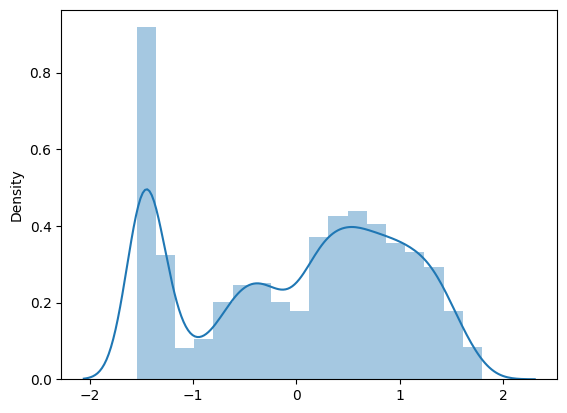

In [8]:
# Plot Standard Normal Distribution (Z-Scores)
print("Standard Normal Distribution for MonthlyCharges:")
z_mean, z_std = univariate.stdNDGraph(df['MonthlyCharges'])

In [9]:
# Check Multicollinearity among continuous variables
continuous_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
vif_table = univariate.cal_vif(df[continuous_cols])
print("Variance Inflation Factor (VIF):")
display(vif_table)

Variance Inflation Factor (VIF):


,variables,VIF
0,tenure,6.332328
1,MonthlyCharges,3.355660
2,TotalCharges,8.075070


***Total charges has high multicollinearity because its value is the product of tenure and monthly charges***

# 1. What is the class balance of target variable(churn)?

In [10]:
df["Churn"].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

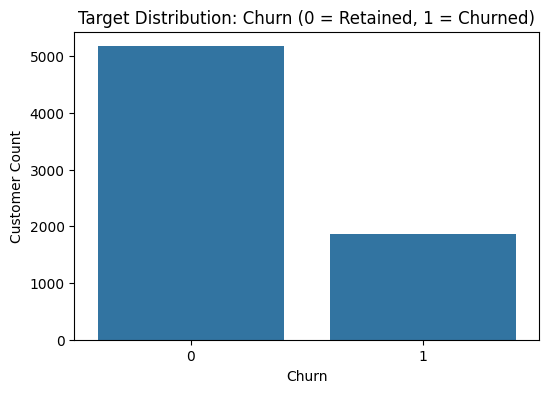

In [11]:
# Count plot for churn
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='Churn', data=df)
plt.title('Target Distribution: Churn (0 = Retained, 1 = Churned)')
plt.xlabel('Churn')
plt.ylabel('Customer Count')
plt.show()

# Bivariate Analysis

# 2. How do higher monthly charges affect customer churn

In [12]:
# Average monthly charges of churned and retained customers
print("Mean Monthly Charges by Churn:")
print(df.groupby('Churn')['MonthlyCharges'].mean())

Mean Monthly Charges by Churn:
Churn
0    61.265124
1    74.441332
Name: MonthlyCharges, dtype: float64


<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

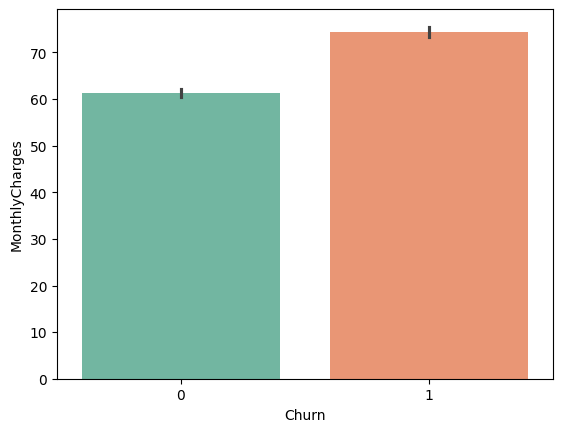

In [13]:
sns.barplot(x = "Churn", y = "MonthlyCharges", data = df,estimator="mean",palette="Set2")

***This shows that monthly charges of churned customers is higher compared to retained customers***

# 3. How does customer tenure influence the likelihood of churn?

***Null hypotheses: There is no significatnt difference between tenure of churned customers and retained customers***

***Alternative hypotheses: There is significatnt difference between tenure of churned customer and retained customer***

In [14]:

from scipy.stats import ttest_ind

churn = df[df["Churn"] == 1]["tenure"]
retained = df[df["Churn"] == 0]["tenure"]

ttest_ind(churn,retained)

TtestResult(statistic=np.float64(-31.57955051135377), pvalue=np.float64(7.99905796059022e-205), df=np.float64(7041.0))

***pvalue<0.05, so we reject null hypothesis***

***Therefore there is significant difference between the tenures of churned and retained customers***

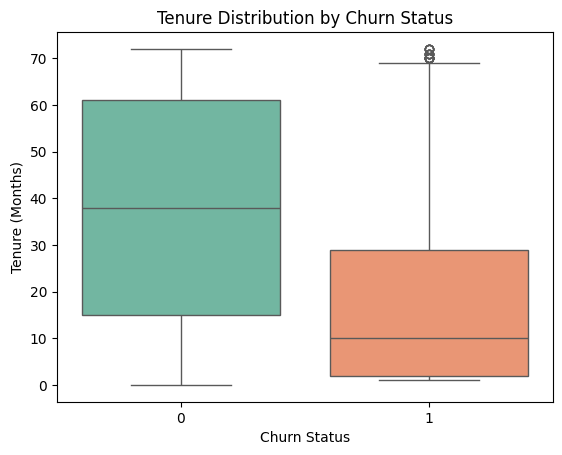

Median Tenure by Churn:
Churn
0    38.0
1    10.0
Name: tenure, dtype: float64


In [15]:
# Boxplot 
sns.boxplot(x='Churn', y='tenure', data=df, palette='Set2')
plt.title('Tenure Distribution by Churn Status')
plt.xlabel('Churn Status')
plt.ylabel('Tenure (Months)')
plt.show()

print("Median Tenure by Churn:")
print(df.groupby('Churn')['tenure'].median())

***This analysis has shown that customers with lower tenure period has churned their services***

# 4. How does contract duration correlate with churn? 

In [16]:
contract_cols = ['Contract_One year', 'Contract_Two year']
contract_means = df.groupby('Churn')[contract_cols].mean()*100
contract_means

,Contract_One year,Contract_Two year
Churn,,
0,25.260920,31.832238
1,8.881755,2.568218


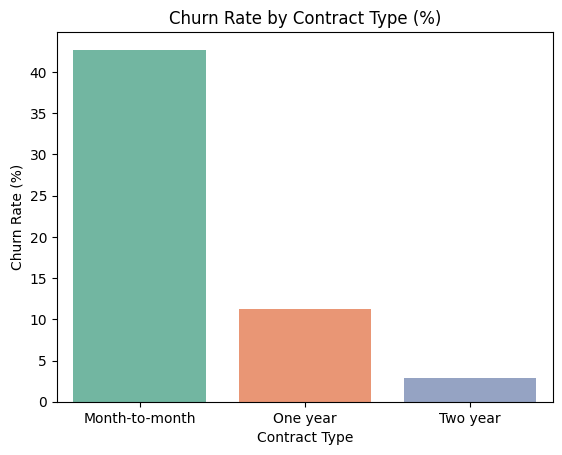

In [17]:
# Simple Bar Plot for Contract vs Churn
contract_churn = [
    df[(df['Contract_One year'] == 0) & (df['Contract_Two year'] == 0)]['Churn'].mean() * 100,
    df[df['Contract_One year'] == 1]['Churn'].mean() * 100,
    df[df['Contract_Two year'] == 1]['Churn'].mean() * 100
]

contracts = ['Month-to-month', 'One year', 'Two year']

sns.barplot(x=contracts, y=contract_churn,palette="Set2")
plt.title('Churn Rate by Contract Type (%)')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')
plt.show()

***This plot shows that customers with yearly contracts tent to retain their service compareted to customers with monthly contracts***

# 5. Does type of service impact churn?

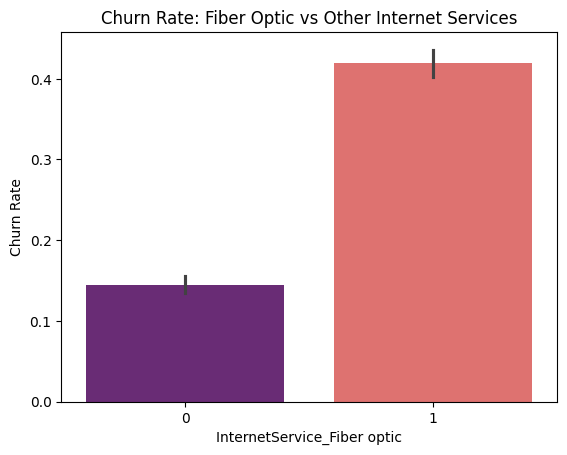

In [18]:
sns.barplot(x='InternetService_Fiber optic', y='Churn', data=df, palette='magma')
plt.title('Churn Rate: Fiber Optic vs Other Internet Services')
plt.ylabel('Churn Rate')
plt.show()

***This show that lot of customers with fiber optic service has churned their service***

# 6. Reason for higher fiber optic connections churned

In [19]:
fiber_df = df[df['InternetService_Fiber optic'] == 1]

# 1. Price Comparison
avg_fiber_bill = fiber_df['MonthlyCharges'].mean()
avg_overall_bill = df['MonthlyCharges'].mean()

print(f"Average Monthly Charge: ${avg_fiber_bill:.2f}")
print(f"Average overall Charge: ${avg_overall_bill:.2f}")

Average Monthly Charge: $91.50
Average overall Charge: $64.76


***Fiber connection customers charges are higher compared to DSL customers so there are higher churn rates***

# 7. How Tech support impact churn?

In [20]:
print("Churn Rate by Tech Support (%):")
print((df.groupby('TechSupport')['Churn'].mean() * 100))

Churn Rate by Tech Support (%):
TechSupport
0    31.186237
1    15.166341
Name: Churn, dtype: float64


# 8. Electronic check impact on churn

In [21]:
print("\nChurn Rate by Electronic Check (%):")
print((df.groupby('PaymentMethod_Electronic check')['Churn'].mean() * 100))


Churn Rate by Electronic Check (%):
PaymentMethod_Electronic check
0    17.058572
1    45.285412
Name: Churn, dtype: float64


***This stats shows that customers with electronic check has higher chances to churn their service*** 

# 9. Which freatures correlate most with churn?

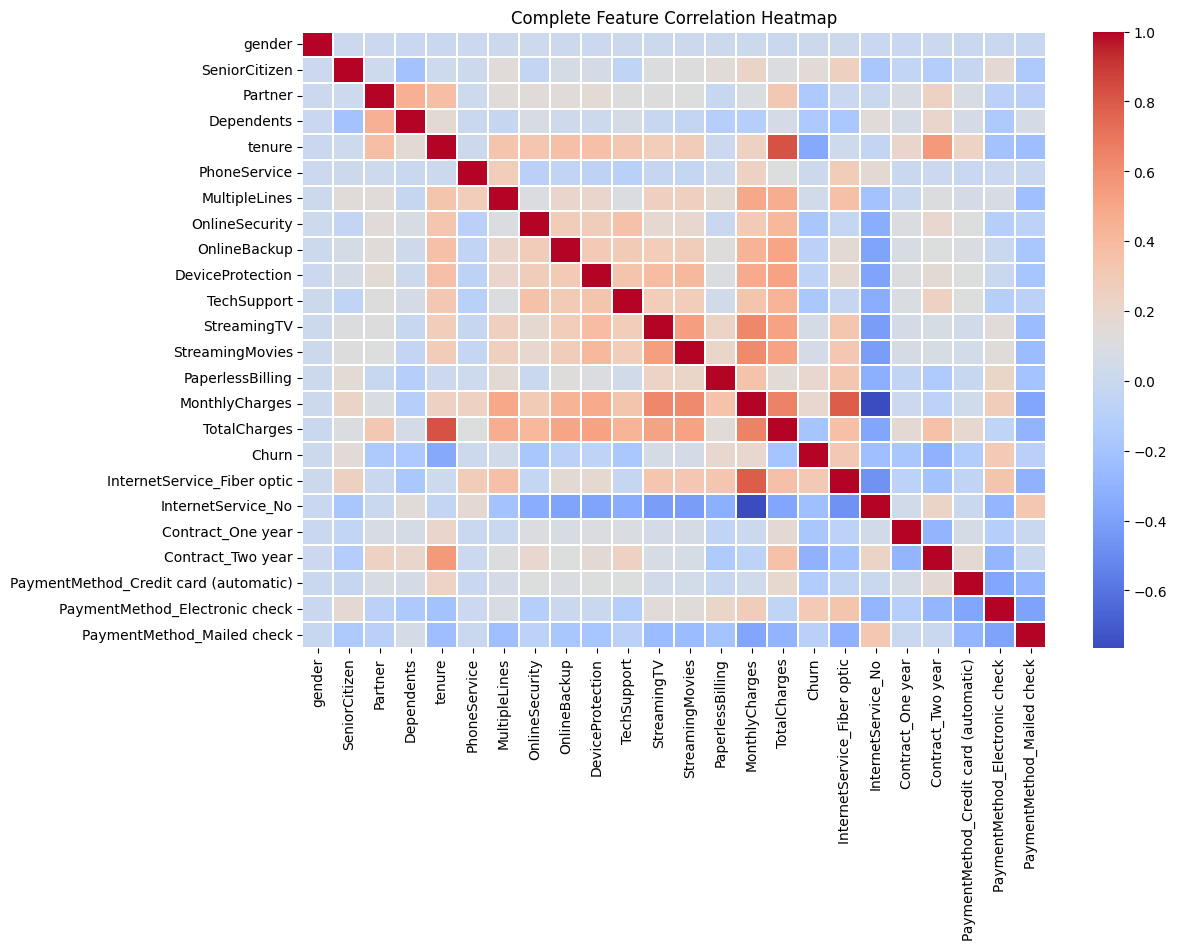

In [22]:
# Full Correlation with Churn
plt.figure(figsize=(12, 8))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, cmap='coolwarm',linewidths=0.2)
plt.title('Complete Feature Correlation Heatmap')
plt.show()


# 10. Top positive and negative correlated features with churn

In [23]:
print("Top 5 Positive Correlations with Churn:")
print(corr_matrix['Churn'].sort_values(ascending=False).iloc[1:6])

print("\nTop 5 Negative Correlations with Churn:")
print(corr_matrix['Churn'].sort_values().head(5))

Top 5 Positive Correlations with Churn:
InternetService_Fiber optic       0.308020
PaymentMethod_Electronic check    0.301919
MonthlyCharges                    0.193356
PaperlessBilling                  0.191825
SeniorCitizen                     0.150889
Name: Churn, dtype: float64

Top 5 Negative Correlations with Churn:
tenure               -0.352229
Contract_Two year    -0.302253
InternetService_No   -0.227890
TotalCharges         -0.198324
Contract_One year    -0.177820
Name: Churn, dtype: float64
